In [1]:
import sys
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")
SRC = str(PROJECT_PATH / "src")

if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(SRC)

/content/drive/MyDrive/UAH_Project/src


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.notebook import tqdm

In [4]:
for p in PROJECT_PATH.rglob("UAH-DRIVESET-v1"):
    print(p)

/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1


In [5]:
DATASET_PATH = PROJECT_PATH / "datasets" / "raw" / "UAH-DRIVESET-v1"

print(DATASET_PATH.exists())
print(DATASET_PATH)

True
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1


In [6]:
video_paths = sorted(DATASET_PATH.rglob("*.mp4"))

print("Video Count :", len(video_paths))

for p in video_paths[:5]:
    print(p.name)

Video Count : 40
20151110175712-16km-D1-NORMAL1-SECONDARY.mp4
20151110180846-16km-D1-NORMAL2-SECONDARY.mp4
20151111123123-25km-D1-NORMAL-MOTORWAY.mp4
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4
20151111132343-25km-D1-DROWSY-MOTORWAY.mp4


In [7]:
video_path = video_paths[0]

cap = cv2.VideoCapture(str(video_path))

print("Opened :", cap.isOpened())

fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS        : {fps}")
print(f"Frames     : {frames}")
print(f"Resolution : {width} x {height}")

cap.release()

Opened : True
FPS        : 29.97305651865157
Frames     : 19134
Resolution : 960 x 540


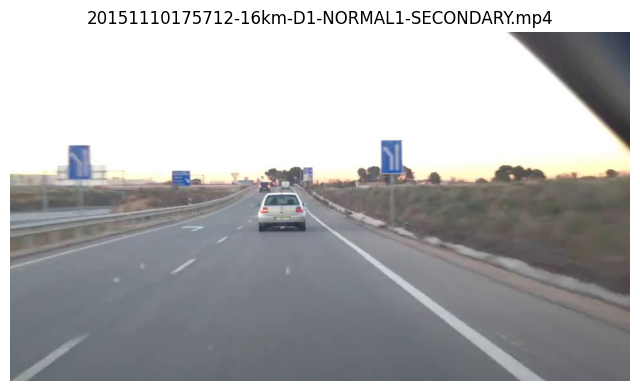

In [8]:
cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()

cap.release()

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(video_path.name)

plt.show()

In [9]:
def compute_dense_flow(video_path, max_frames=300):

    cap = cv2.VideoCapture(str(video_path))

    ret, prev = cap.read()

    if not ret:
        return []

    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    flow_images = []

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            gray,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        magnitude, angle = cv2.cartToPolar(
            flow[...,0],
            flow[...,1]
        )

        hsv = np.zeros_like(frame)

        hsv[...,1] = 255

        hsv[...,0] = angle * 180 / np.pi / 2

        hsv[...,2] = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        rgb = cv2.cvtColor(
            hsv,
            cv2.COLOR_HSV2RGB
        )

        flow_images.append(rgb)

        prev_gray = gray

        frame_count += 1

        if frame_count >= max_frames:
            break

    cap.release()

    return flow_images

In [10]:
flow_images = compute_dense_flow(video_path)

print(len(flow_images))

300


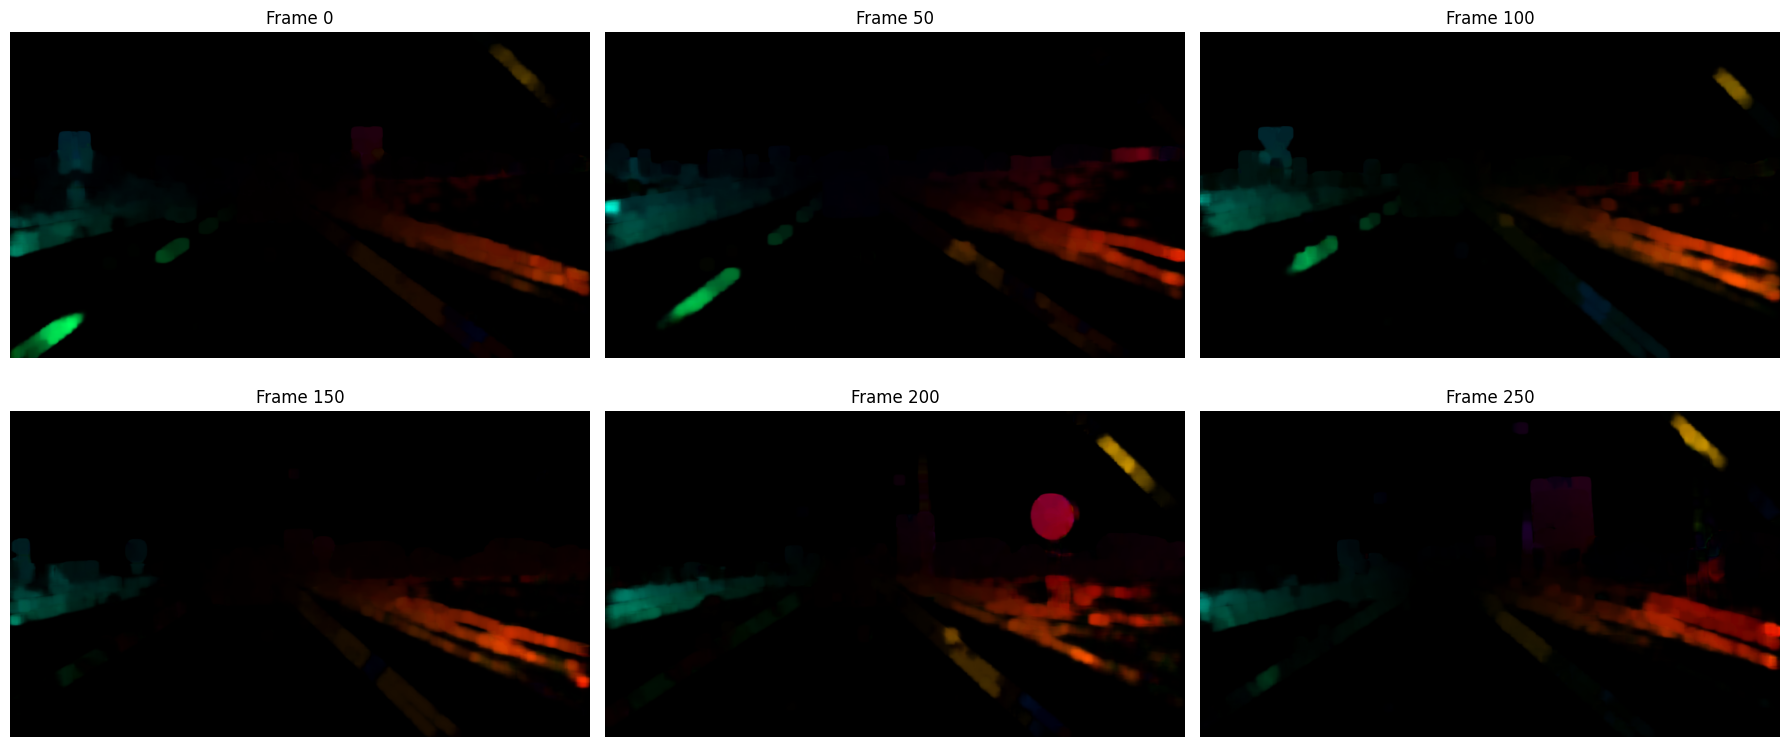

In [11]:
plt.figure(figsize=(18,8))

indices = [0,50,100,150,200,250]

for i,idx in enumerate(indices):

    plt.subplot(2,3,i+1)

    plt.imshow(flow_images[idx])

    plt.axis("off")

    plt.title(f"Frame {idx}")

plt.tight_layout()

plt.show()

In [12]:
OUTPUT_DIR = PROJECT_PATH / "datasets" / "optical_flow"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(OUTPUT_DIR)

/content/drive/MyDrive/UAH_Project/datasets/optical_flow


In [13]:
def save_optical_flow_video(
    video_path,
    output_path,
    resize=(320, 180)
):

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)

    ret, prev = cap.read()

    if not ret:
        print("Video okunamadı.")
        return

    prev = cv2.resize(prev, resize)

    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        resize
    )

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, resize)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            gray,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        mag, ang = cv2.cartToPolar(
            flow[...,0],
            flow[...,1]
        )

        hsv = np.zeros_like(frame)

        hsv[...,1] = 255
        hsv[...,0] = ang * 180 / np.pi / 2
        hsv[...,2] = cv2.normalize(
            mag,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        rgb = cv2.cvtColor(
            hsv,
            cv2.COLOR_HSV2BGR
        )

        writer.write(rgb)

        prev_gray = gray

    cap.release()
    writer.release()

    print("Saved:", output_path)

In [14]:
video_path = video_paths[0]

output_path = OUTPUT_DIR / (
    video_path.stem + "_flow.mp4"
)

save_optical_flow_video(
    video_path,
    output_path
)

Saved: /content/drive/MyDrive/UAH_Project/datasets/optical_flow/20151110175712-16km-D1-NORMAL1-SECONDARY_flow.mp4


In [15]:
print(output_path.exists())
print(output_path)

True
/content/drive/MyDrive/UAH_Project/datasets/optical_flow/20151110175712-16km-D1-NORMAL1-SECONDARY_flow.mp4


In [16]:
def save_flow_numpy(video_path, output_path, resize=(320,180)):

    cap = cv2.VideoCapture(str(video_path))

    ret, prev = cap.read()

    if not ret:
        return

    prev = cv2.resize(prev, resize)
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    flows = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, resize)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            gray,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        flows.append(flow.astype(np.float32))

        prev_gray = gray

    cap.release()

    flows = np.array(flows)

    np.save(output_path, flows)

    print(flows.shape)

In [17]:
flow_path = OUTPUT_DIR / (video_path.stem + "_flow.npy")

save_flow_numpy(
    video_path,
    flow_path
)

(19133, 180, 320, 2)


In [18]:
flow = np.load(flow_path)

print(flow.shape)
print(flow.dtype)

print("Min :", flow.min())
print("Max :", flow.max())
print("Mean:", flow.mean())
print("Std :", flow.std())

(19133, 180, 320, 2)
float32
Min : -378.2246
Max : 147.42253
Mean: 0.46035075
Std : 2.4672465


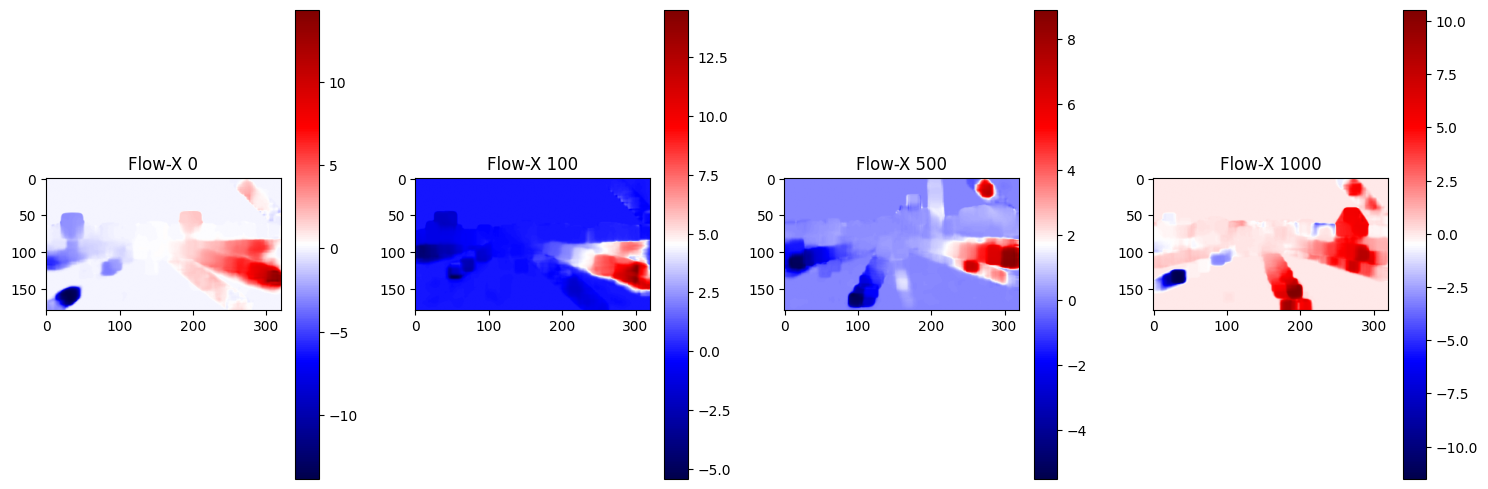

In [19]:
plt.figure(figsize=(15,5))

for i, idx in enumerate([0,100,500,1000]):

    plt.subplot(1,4,i+1)

    plt.imshow(flow[idx,:,:,0], cmap="seismic")

    plt.title(f"Flow-X {idx}")

    plt.colorbar()

plt.tight_layout()
plt.show()

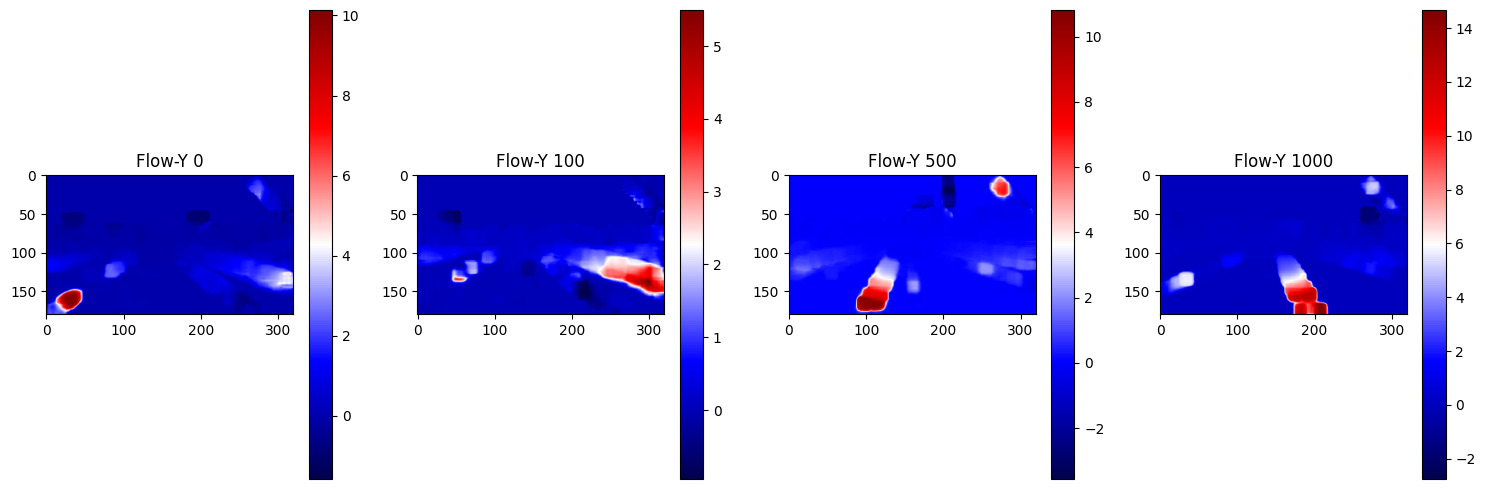

In [20]:
plt.figure(figsize=(15,5))

for i, idx in enumerate([0,100,500,1000]):

    plt.subplot(1,4,i+1)

    plt.imshow(flow[idx,:,:,1], cmap="seismic")

    plt.title(f"Flow-Y {idx}")

    plt.colorbar()

plt.tight_layout()
plt.show()

In [21]:
label_map = {
    "NORMAL": 0,
    "DROWSY": 1,
    "AGGRESSIVE": 2
}

def get_label(video_name):

    if "NORMAL" in video_name:
        return label_map["NORMAL"]

    if "DROWSY" in video_name:
        return label_map["DROWSY"]

    if "AGGRESSIVE" in video_name:
        return label_map["AGGRESSIVE"]

    raise ValueError(video_name)

In [22]:
for p in video_paths[:5]:

    print(
        p.name,
        get_label(p.name)
    )

20151110175712-16km-D1-NORMAL1-SECONDARY.mp4 0
20151110180846-16km-D1-NORMAL2-SECONDARY.mp4 0
20151111123123-25km-D1-NORMAL-MOTORWAY.mp4 0
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4 2
20151111132343-25km-D1-DROWSY-MOTORWAY.mp4 1


In [23]:
def mean_pool_flow(flow, block_size=15):

    pooled = []

    for i in range(0, len(flow), block_size):

        block = flow[i:i+block_size]

        if len(block) < block_size:
            break

        pooled.append(block.mean(axis=0))

    return np.array(pooled)

In [24]:
flow = np.load(flow_path)

pooled_flow = mean_pool_flow(flow)

print(flow.shape)
print(pooled_flow.shape)

(19133, 180, 320, 2)
(1275, 180, 320, 2)


In [25]:
magnitude = np.sqrt(
    flow[:,:,:,0]**2 +
    flow[:,:,:,1]**2
)

print(magnitude.shape)

(19133, 180, 320)


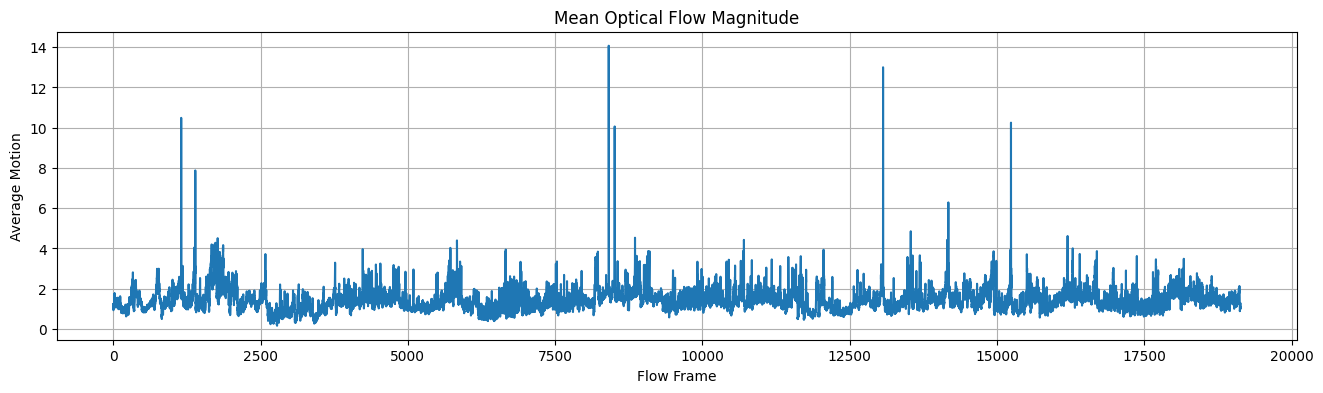

In [26]:
mean_mag = magnitude.mean(axis=(1,2))

plt.figure(figsize=(16,4))

plt.plot(mean_mag)

plt.grid(True)

plt.title("Mean Optical Flow Magnitude")

plt.xlabel("Flow Frame")

plt.ylabel("Average Motion")

plt.show()

In [27]:
pooled_mag = np.sqrt(
    pooled_flow[:,:,:,0]**2 +
    pooled_flow[:,:,:,1]**2
)

pooled_mean = pooled_mag.mean(axis=(1,2))

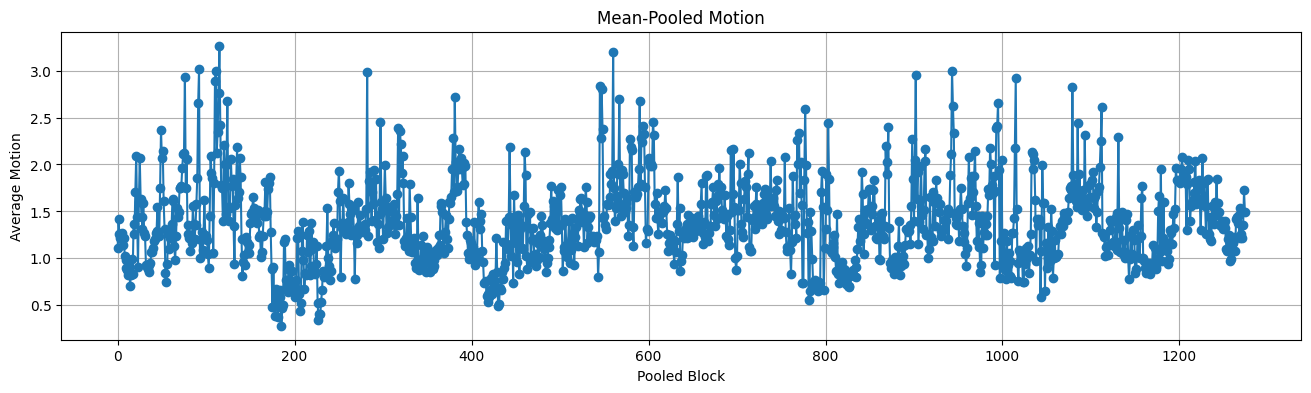

In [28]:
plt.figure(figsize=(16,4))

plt.plot(
    pooled_mean,
    marker="o"
)

plt.grid(True)

plt.title("Mean-Pooled Motion")

plt.xlabel("Pooled Block")

plt.ylabel("Average Motion")

plt.show()

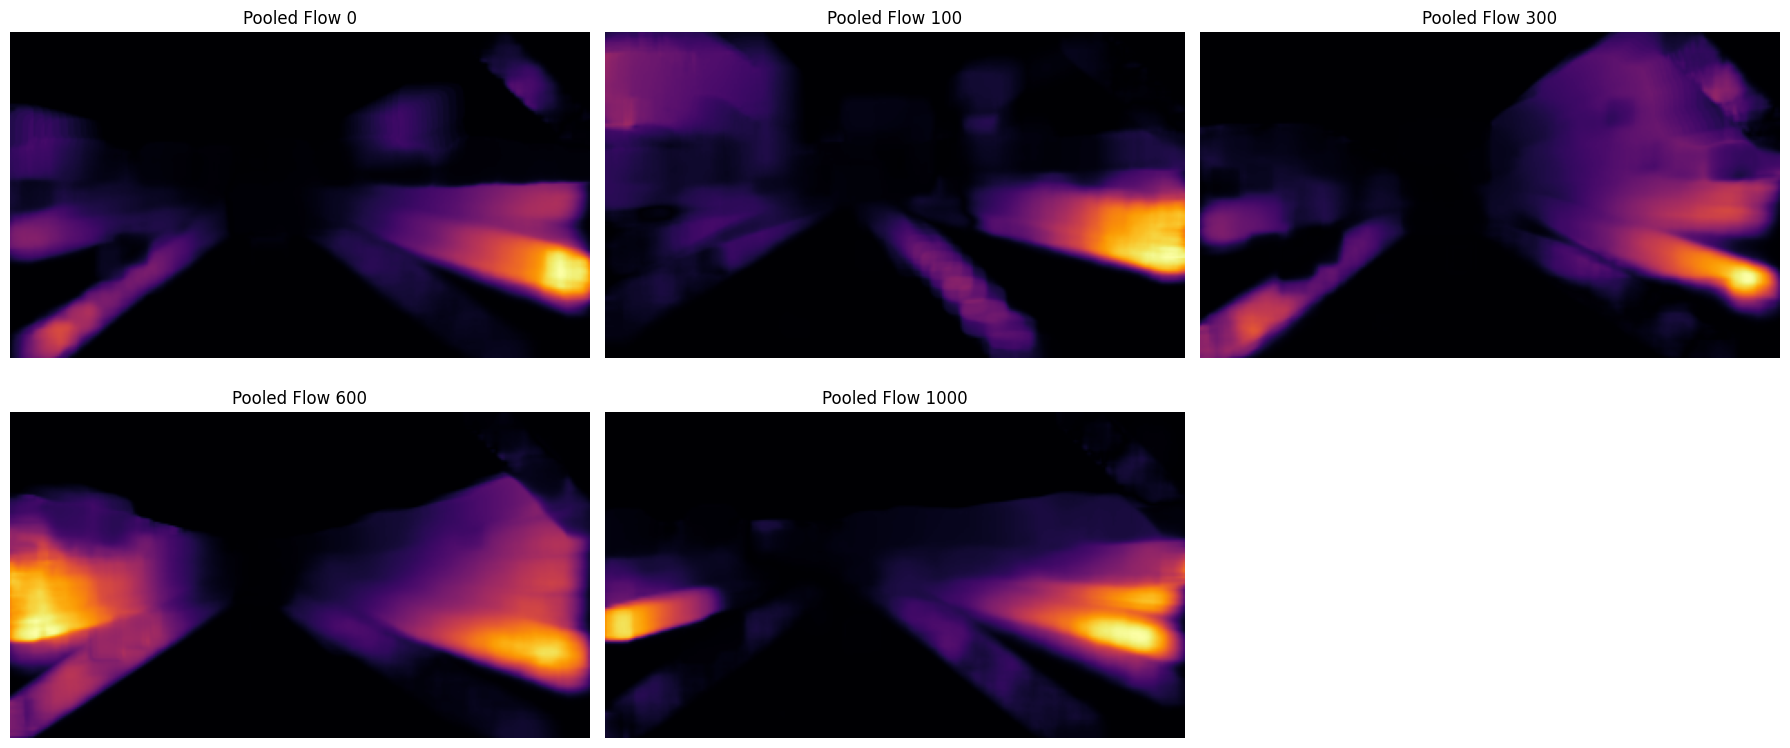

In [29]:
plt.figure(figsize=(18,8))

indices = [0,100,300,600,1000]

for i, idx in enumerate(indices):

    mag = np.sqrt(
        pooled_flow[idx,:,:,0]**2 +
        pooled_flow[idx,:,:,1]**2
    )

    plt.subplot(2,3,i+1)

    plt.imshow(
        mag,
        cmap="inferno"
    )

    plt.title(f"Pooled Flow {idx}")

    plt.axis("off")

plt.tight_layout()

plt.show()

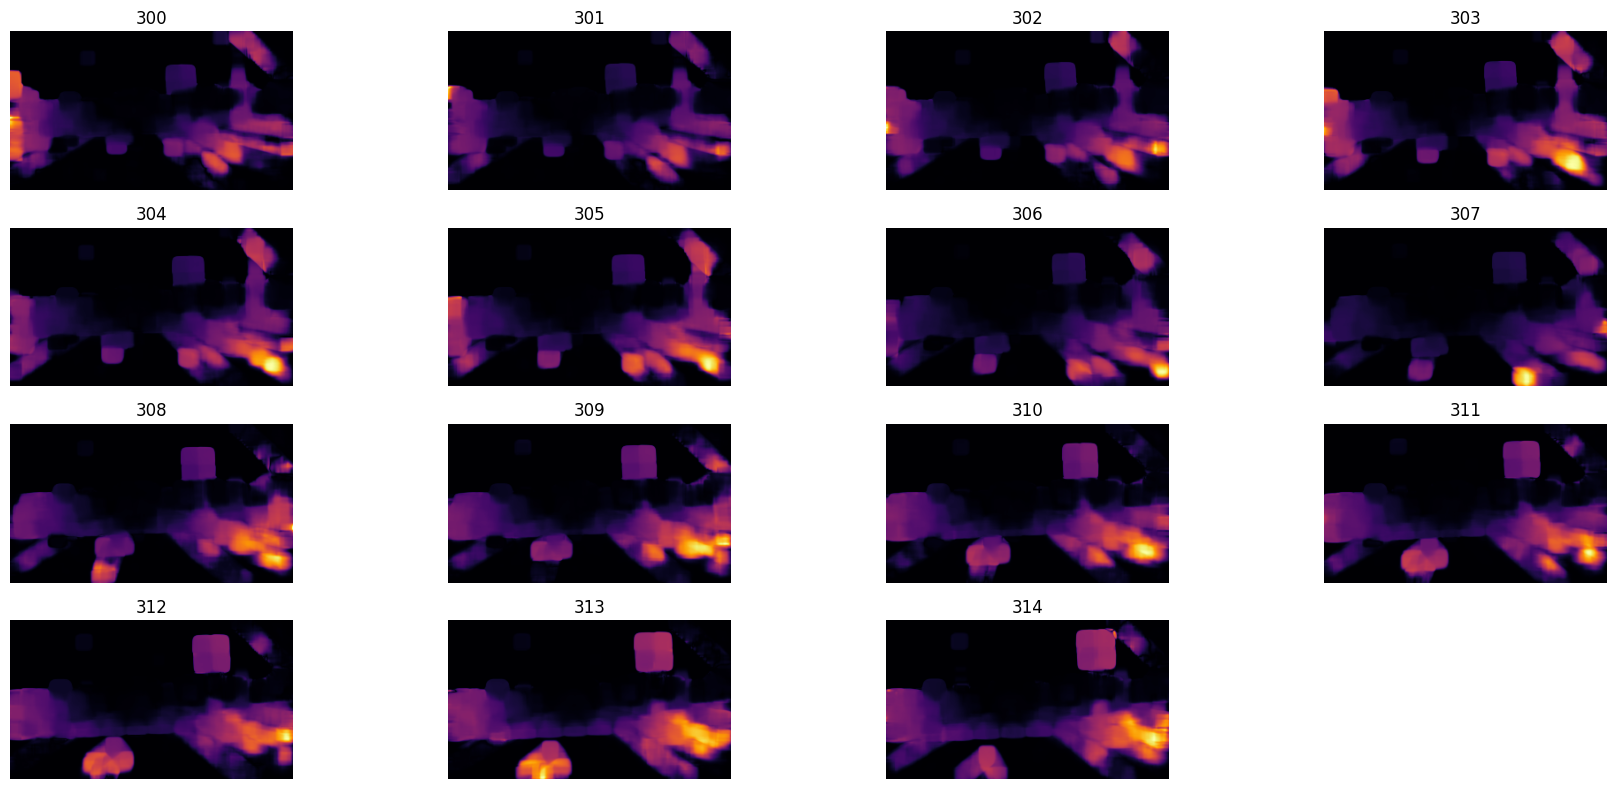

In [30]:
idx = 300

plt.figure(figsize=(18,8))

for i in range(15):

    plt.subplot(4,4,i+1)

    mag = np.sqrt(
        flow[idx+i,:,:,0]**2 +
        flow[idx+i,:,:,1]**2
    )

    plt.imshow(mag, cmap="inferno")
    plt.axis("off")
    plt.title(f"{idx+i}")

plt.tight_layout()
plt.show()

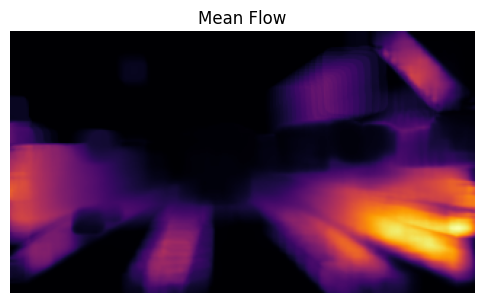

In [31]:
plt.figure(figsize=(6,6))

mag = np.sqrt(
    pooled_flow[idx//15,:,:,0]**2 +
    pooled_flow[idx//15,:,:,1]**2
)

plt.imshow(mag,cmap="inferno")
plt.axis("off")
plt.title("Mean Flow")
plt.show()

In [32]:
def create_flow_windows(
        flow,
        window_size=360,
        stride=180,
        pool_size=15):

    windows = []

    for start in range(
            0,
            len(flow)-window_size+1,
            stride):

        window = flow[start:start+window_size]

        pooled = []

        for i in range(
                0,
                window_size,
                pool_size):

            pooled.append(
                window[i:i+pool_size].mean(axis=0)
            )

        windows.append(
            np.stack(pooled)
        )

    return np.array(windows)

In [33]:
video_windows = create_flow_windows(flow)

print(video_windows.shape)

(105, 24, 180, 320, 2)


In [34]:
print(video_windows[0].shape)

(24, 180, 320, 2)


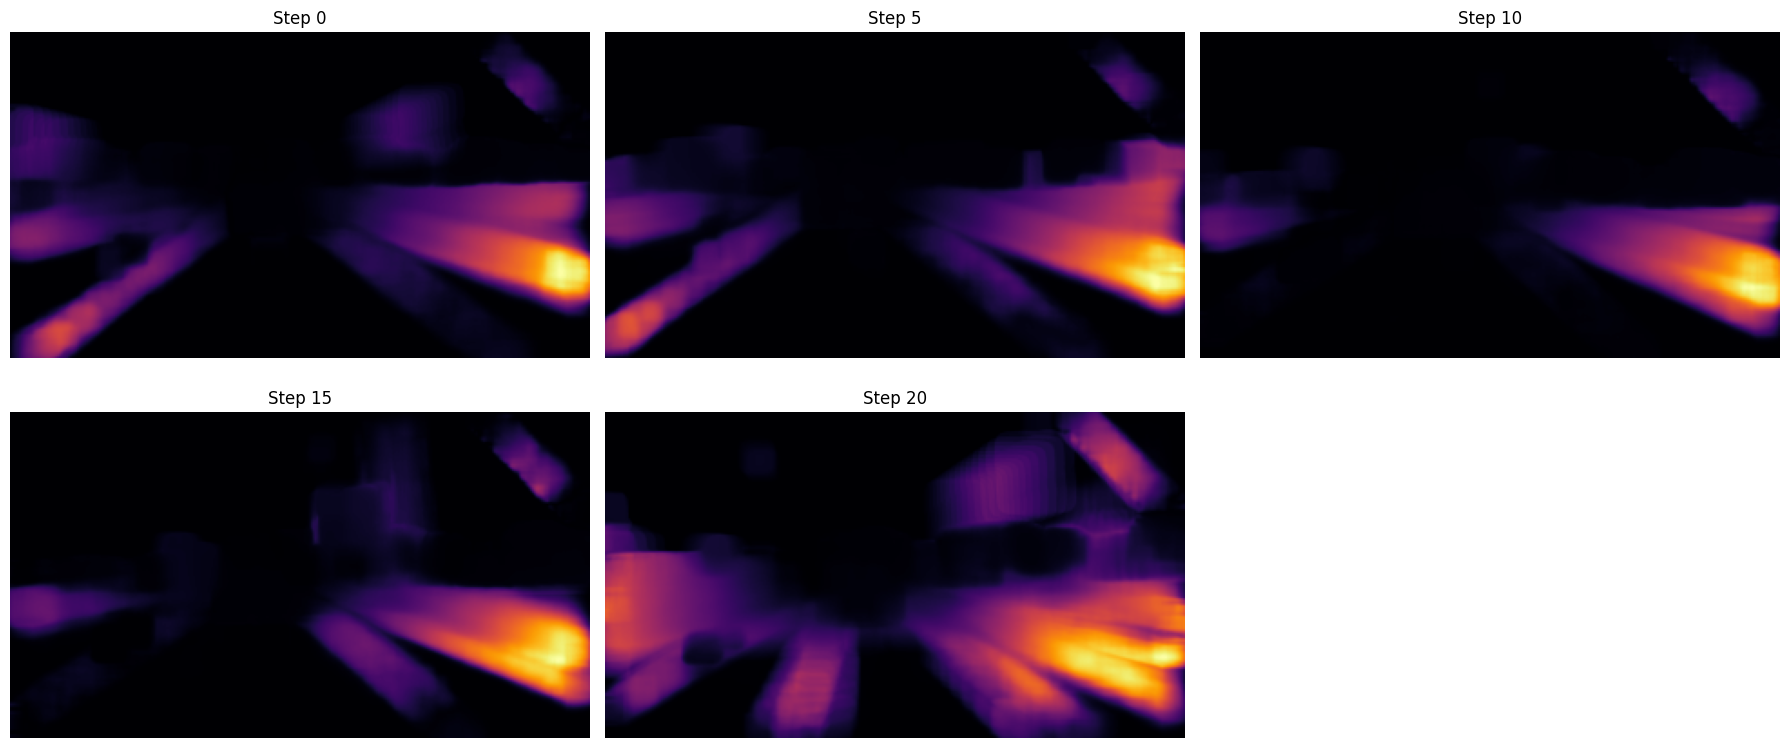

In [35]:
plt.figure(figsize=(18,8))

indices=[0,5,10,15,20]

for i,idx in enumerate(indices):

    mag=np.sqrt(
        video_windows[0,idx,:,:,0]**2+
        video_windows[0,idx,:,:,1]**2
    )

    plt.subplot(2,3,i+1)

    plt.imshow(
        mag,
        cmap="inferno"
    )

    plt.title(f"Step {idx}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
PROCESSED_DIR = OUTPUT_DIR / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [37]:
for video_path in video_paths:

    print(video_path.name)

20151110175712-16km-D1-NORMAL1-SECONDARY.mp4
20151110180846-16km-D1-NORMAL2-SECONDARY.mp4
20151111123123-25km-D1-NORMAL-MOTORWAY.mp4
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4
20151111132343-25km-D1-DROWSY-MOTORWAY.mp4
20151111134542-16km-D1-AGGRESSIVE-SECONDARY..mp4
20151111135605-13km-D1-DROWSY-SECONDARY.mp4
20151120131704-26km-D2-NORMAL-MOTORWAY.mp4
20151120133457-26km-D2-AGGRESSIVE-MOTORWAY.mp4
20151120135150-25km-D2-DROWSY-MOTORWAY.mp4
20151120160903-16km-D2-NORMAL1-SECONDARY.mp4
20151120162104-17km-D2-NORMAL2-SECONDARY.mp4
20151120163335-16km-D2-AGGRESSIVE-SECONDARY.mp4
20151120165604-16km-D2-DROWSY-SECONDARY.mp4
20151126110501-26km-D3-NORMAL-MOTORWAY.mp4
20151126113753-26km-D3-DROWSY-MOTORWAY.mp4
20151126124207-16km-D3-NORMAL1-SECONDARY.mp4
20151126125500-16km-D3-NORMAL2-SECONDARY.mp4
20151126130708-16km-D3-AGGRESSIVE-SECONDARY.mp4
20151126132012-16km-D3-DROWSY-SECONDARY.mp4
20151126134731-26km-D3-AGGRESSIVE-MOTORWAY.mp4
20151203171759-16km-D4-NORMAL1-SECONDARY.mp4
201512031

In [38]:
print(len(list(OUTPUT_DIR.glob("*_flow.npy"))))

for p in OUTPUT_DIR.glob("*_flow.npy"):
    print(p.name)

6
20151110175712-16km-D1-NORMAL1-SECONDARY_flow.npy
20151110180846-16km-D1-NORMAL2-SECONDARY_flow.npy
20151111123123-25km-D1-NORMAL-MOTORWAY_flow.npy
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_flow.npy
20151111132343-25km-D1-DROWSY-MOTORWAY_flow.npy
20151111134542-16km-D1-AGGRESSIVE-SECONDARY._flow.npy


In [39]:
for video_path in tqdm(video_paths):

    output_path = OUTPUT_DIR / (video_path.stem + "_flow.npy")

    if output_path.exists():
        continue

    save_flow_numpy(
        video_path,
        output_path
    )

  0%|          | 0/40 [00:00<?, ?it/s]

(15950, 180, 320, 2)
(29024, 180, 320, 2)
(26594, 180, 320, 2)
(28717, 180, 320, 2)
(19813, 180, 320, 2)
(20941, 180, 320, 2)
(19203, 180, 320, 2)
(19990, 180, 320, 2)
(28017, 180, 320, 2)
(31002, 180, 320, 2)
(21330, 180, 320, 2)
(20258, 180, 320, 2)
(20638, 180, 320, 2)
(16965, 180, 320, 2)
(25657, 180, 320, 2)
(22166, 180, 320, 2)
(21105, 180, 320, 2)
(20200, 180, 320, 2)
(17557, 180, 320, 2)
(30549, 180, 320, 2)
(28313, 180, 320, 2)
(31060, 180, 320, 2)
(28117, 180, 320, 2)
(24313, 180, 320, 2)
(33147, 180, 320, 2)
(21395, 180, 320, 2)
(21104, 180, 320, 2)
(17472, 180, 320, 2)
(21374, 180, 320, 2)
(31212, 180, 320, 2)
(35916, 180, 320, 2)
(23717, 180, 320, 2)
(22728, 180, 320, 2)
(27917, 180, 320, 2)


In [40]:
for video_path in video_paths:

    flow_path = OUTPUT_DIR / (video_path.stem + "_flow.npy")

    flow = np.load(flow_path)

    windows = create_flow_windows(flow)

    save_path = PROCESSED_DIR / (video_path.stem + "_windows.npy")

    np.save(save_path, windows)

    print(
        video_path.name,
        windows.shape
    )

20151110175712-16km-D1-NORMAL1-SECONDARY.mp4 (105, 24, 180, 320, 2)
20151110180846-16km-D1-NORMAL2-SECONDARY.mp4 (101, 24, 180, 320, 2)
20151111123123-25km-D1-NORMAL-MOTORWAY.mp4 (145, 24, 180, 320, 2)
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4 (129, 24, 180, 320, 2)
20151111132343-25km-D1-DROWSY-MOTORWAY.mp4 (158, 24, 180, 320, 2)
20151111134542-16km-D1-AGGRESSIVE-SECONDARY..mp4 (89, 24, 180, 320, 2)
20151111135605-13km-D1-DROWSY-SECONDARY.mp4 (87, 24, 180, 320, 2)
20151120131704-26km-D2-NORMAL-MOTORWAY.mp4 (160, 24, 180, 320, 2)
20151120133457-26km-D2-AGGRESSIVE-MOTORWAY.mp4 (146, 24, 180, 320, 2)
20151120135150-25km-D2-DROWSY-MOTORWAY.mp4 (158, 24, 180, 320, 2)
20151120160903-16km-D2-NORMAL1-SECONDARY.mp4 (109, 24, 180, 320, 2)
20151120162104-17km-D2-NORMAL2-SECONDARY.mp4 (115, 24, 180, 320, 2)
20151120163335-16km-D2-AGGRESSIVE-SECONDARY.mp4 (105, 24, 180, 320, 2)
20151120165604-16km-D2-DROWSY-SECONDARY.mp4 (110, 24, 180, 320, 2)
20151126110501-26km-D3-NORMAL-MOTORWAY.mp4 (154, 

In [41]:
import pandas as pd

metadata = []

for group_id, video_path in enumerate(video_paths):

    save_path = PROCESSED_DIR / (video_path.stem + "_windows.npy")

    windows = np.load(save_path, mmap_mode="r")

    metadata.append({
        "file": save_path.name,
        "label": get_label(video_path.name),
        "label_name": (
            "NORMAL"
            if get_label(video_path.name)==0
            else
            "DROWSY"
            if get_label(video_path.name)==1
            else
            "AGGRESSIVE"
        ),
        "group": group_id,
        "windows": len(windows)
    })

metadata = pd.DataFrame(metadata)

metadata

,file,label,label_name,group,windows
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,NORMAL,0,105
1,20151110180846-16km-D1-NORMAL2-SECONDARY_windo...,0,NORMAL,1,101
2,20151111123123-25km-D1-NORMAL-MOTORWAY_windows...,0,NORMAL,2,145
3,20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,3,129
4,20151111132343-25km-D1-DROWSY-MOTORWAY_windows...,1,DROWSY,4,158
5,20151111134542-16km-D1-AGGRESSIVE-SECONDARY._w...,2,AGGRESSIVE,5,89
6,20151111135605-13km-D1-DROWSY-SECONDARY_window...,1,DROWSY,6,87
7,20151120131704-26km-D2-NORMAL-MOTORWAY_windows...,0,NORMAL,7,160
8,20151120133457-26km-D2-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,8,146
9,20151120135150-25km-D2-DROWSY-MOTORWAY_windows...,1,DROWSY,9,158


In [42]:
metadata.to_csv(
    PROCESSED_DIR / "metadata.csv",
    index=False
)

metadata

,file,label,label_name,group,windows
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,NORMAL,0,105
1,20151110180846-16km-D1-NORMAL2-SECONDARY_windo...,0,NORMAL,1,101
2,20151111123123-25km-D1-NORMAL-MOTORWAY_windows...,0,NORMAL,2,145
3,20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,3,129
4,20151111132343-25km-D1-DROWSY-MOTORWAY_windows...,1,DROWSY,4,158
5,20151111134542-16km-D1-AGGRESSIVE-SECONDARY._w...,2,AGGRESSIVE,5,89
6,20151111135605-13km-D1-DROWSY-SECONDARY_window...,1,DROWSY,6,87
7,20151120131704-26km-D2-NORMAL-MOTORWAY_windows...,0,NORMAL,7,160
8,20151120133457-26km-D2-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,8,146
9,20151120135150-25km-D2-DROWSY-MOTORWAY_windows...,1,DROWSY,9,158


In [43]:
print(metadata)

print()

print(metadata.groupby("label_name")["windows"].sum())

                                                 file  label  label_name  \
0   20151110175712-16km-D1-NORMAL1-SECONDARY_windo...      0      NORMAL   
1   20151110180846-16km-D1-NORMAL2-SECONDARY_windo...      0      NORMAL   
2   20151111123123-25km-D1-NORMAL-MOTORWAY_windows...      0      NORMAL   
3   20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_win...      2  AGGRESSIVE   
4   20151111132343-25km-D1-DROWSY-MOTORWAY_windows...      1      DROWSY   
5   20151111134542-16km-D1-AGGRESSIVE-SECONDARY._w...      2  AGGRESSIVE   
6   20151111135605-13km-D1-DROWSY-SECONDARY_window...      1      DROWSY   
7   20151120131704-26km-D2-NORMAL-MOTORWAY_windows...      0      NORMAL   
8   20151120133457-26km-D2-AGGRESSIVE-MOTORWAY_win...      2  AGGRESSIVE   
9   20151120135150-25km-D2-DROWSY-MOTORWAY_windows...      1      DROWSY   
10  20151120160903-16km-D2-NORMAL1-SECONDARY_windo...      0      NORMAL   
11  20151120162104-17km-D2-NORMAL2-SECONDARY_windo...      0      NORMAL   
12  20151120